
# 4. Análisis básico de datos 



## 4.1. Matríz de correlación entre variables

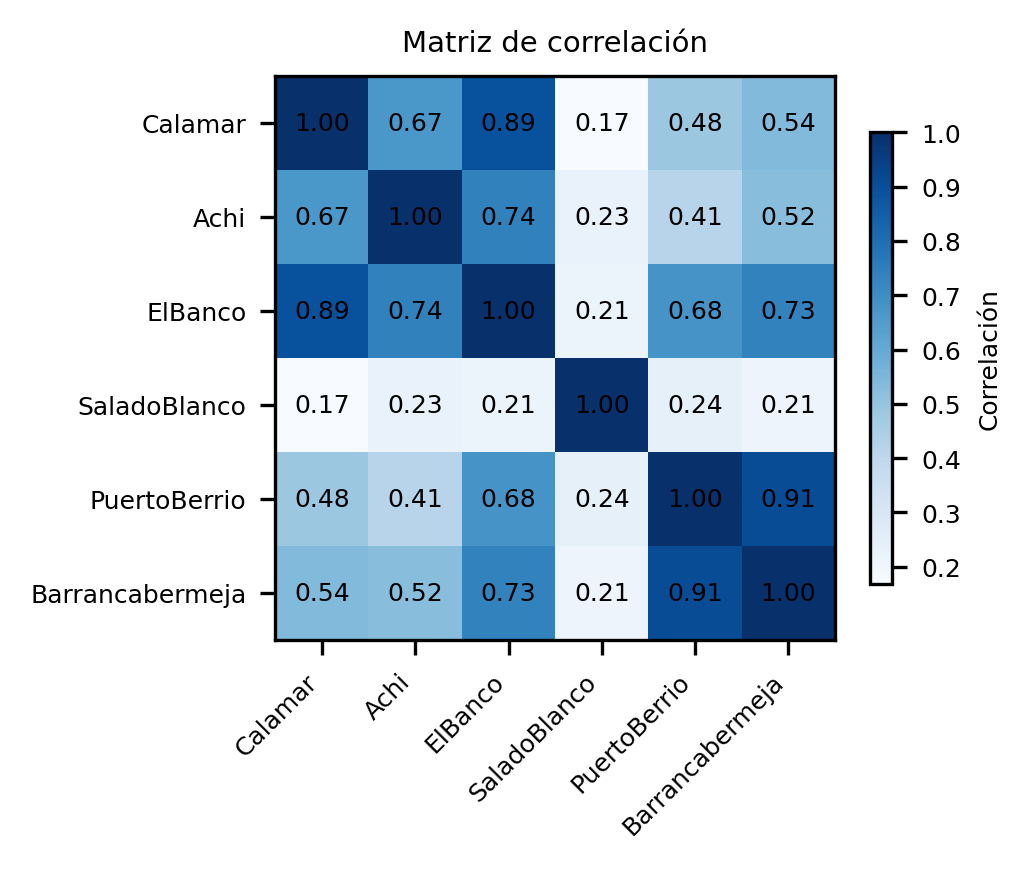

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resetear estilos globales
#sns.reset_defaults()
#plt.rcdefaults()
#plt.style.use("default")

# Matriz de correlación
ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

corr = df[["Calamar", "Achi", "ElBanco","SaladoBlanco", "PuertoBerrio","Barrancabermeja"]].corr().round(3)

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
im = ax.imshow(corr, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=6)
ax.set_yticklabels(corr.index, fontsize=6)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

cbar = plt.colorbar(im, ax=ax, label="Correlación", shrink=0.8)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("Correlación", fontsize=6)

plt.title("Matriz de correlación", fontsize=7)
plt.tight_layout()
plt.show()

## 4.2. Diagramas de dispersión

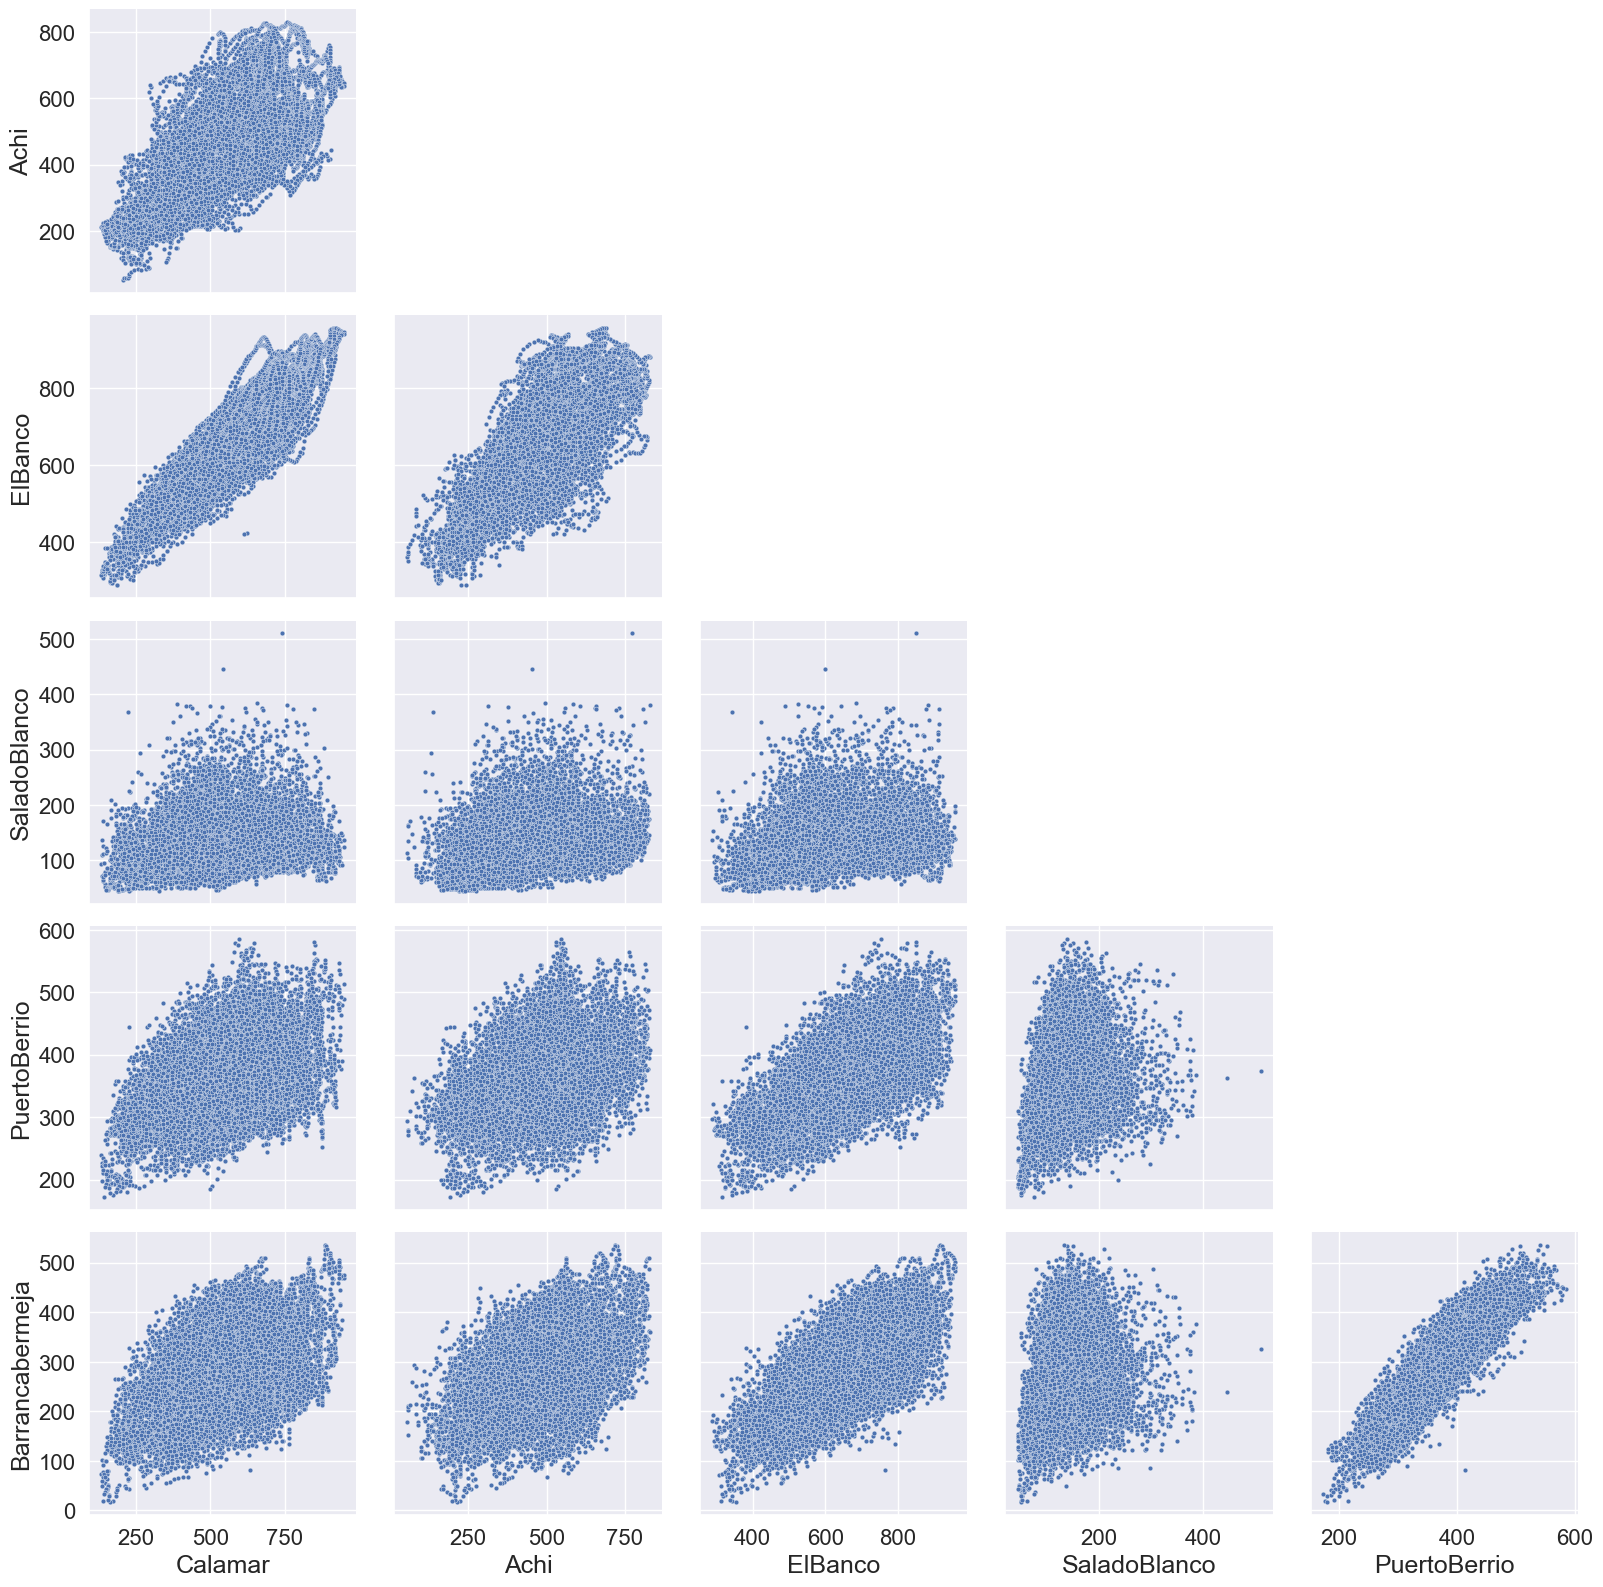

In [45]:
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["Calamar", "Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.simplefilter("ignore", DeprecationWarning)

    sns.set_theme(context="notebook", font_scale=1.0)

    g = sns.PairGrid(
        df[cols].dropna(),
        corner=True,
        height=3.2,
        aspect=1.0
    )
    g.map_lower(sns.scatterplot, alpha=1, s=12)

    for i in range(len(cols)):
        g.axes[i, i].set_visible(False)

    # Aumentar tamaño de etiquetas y ticks
    for ax_row in g.axes:
        for ax in ax_row:
            if ax is not None:
                ax.set_xlabel(ax.get_xlabel(), fontsize=18)
                ax.set_ylabel(ax.get_ylabel(), fontsize=18)
                ax.tick_params(axis="both", labelsize=16)

plt.show()



## 4.3. Factor de inflacion de la Varianza (VIF)

In [41]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar solo las variables explicativas
X = df[["Achi", "ElBanco","SaladoBlanco", "PuertoBerrio","Barrancabermeja"]].dropna().copy()

# Calcular VIF
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,Variable,VIF
0,PuertoBerrio,85.968766
1,ElBanco,78.607905
2,Barrancabermeja,42.148871
3,Achi,28.258192
4,SaladoBlanco,9.712156
